# Talento Altamente Especializado (TAE) en Inteligencia Artificial
## Módulo 4 — Notebook 2.3: Deep Neural Networks

**Nombre:** Alejandro Campos Martínez  
**Módulo:** 4  
**Programa:** Talento Altamente Especializado (TAE) en Inteligencia Artificial  
**Instructor:** German Alonso Pinedo Diaz  
**Lugar:** Tepic, Nayarit  
**Fecha:** 13 de junio de 2026

---

In [1]:
# Imports math library
import numpy as np
# Imports plotting library
import matplotlib.pyplot as plt

In [2]:
# Define the Rectified Linear Unit (ReLU) function
def ReLU(preactivation):
  activation = preactivation.clip(0.0)
  return activation

In [3]:
# Define a shallow neural network with, one input, one output, and three hidden units
def shallow_1_1_3(x, activation_fn, phi_0,phi_1,phi_2,phi_3, theta_10, theta_11, theta_20, theta_21, theta_30, theta_31):
  # Initial lines
  pre_1 = theta_10 + theta_11 * x
  pre_2 = theta_20 + theta_21 * x
  pre_3 = theta_30 + theta_31 * x
  # Activation functions
  act_1 = activation_fn(pre_1)
  act_2 = activation_fn(pre_2)
  act_3 = activation_fn(pre_3)
  # Weight activations
  w_act_1 = phi_1 * act_1
  w_act_2 = phi_2 * act_2
  w_act_3 = phi_3 * act_3
  # Combine weighted activation and add y offset
  y = phi_0 + w_act_1 + w_act_2 + w_act_3
  # Return everything we have calculated
  return y, pre_1, pre_2, pre_3, act_1, act_2, act_3, w_act_1, w_act_2, w_act_3

In [4]:
# # Plot the shallow neural network.  We'll assume input in is range [-1,1] and output [-1,1]
def plot_neural(x, y):
  fig, ax = plt.subplots()
  ax.plot(x.T,y.T)
  ax.set_xlabel('Input'); ax.set_ylabel('Output')
  ax.set_xlim([-1,1]);ax.set_ylim([-1,1])
  ax.set_aspect(1.0)
  plt.show()

Let's define a network.  We'll just consider the inputs and outputs over the range [-1,1].

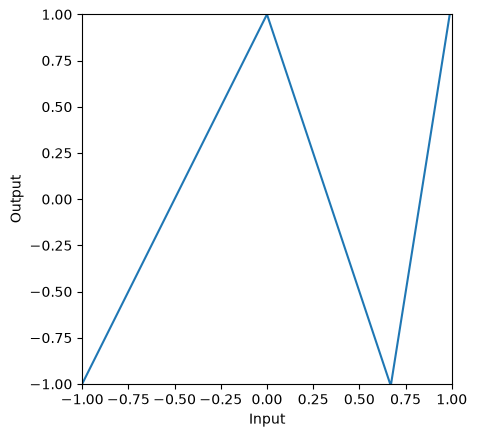

In [5]:
# Now lets define some parameters and run the first neural network
n1_theta_10 = 0.0   ; n1_theta_11 = -1.0
n1_theta_20 = 0     ; n1_theta_21 = 1.0
n1_theta_30 = -0.67 ; n1_theta_31 =  1.0
n1_phi_0 = 1.0; n1_phi_1 = -2.0; n1_phi_2 = -3.0; n1_phi_3 = 9.3

# Define a range of input values
n1_in = np.arange(-1,1,0.01).reshape([1,-1])

# We run the neural network for each of these input values
n1_out, *_ = shallow_1_1_3(n1_in, ReLU, n1_phi_0, n1_phi_1, n1_phi_2, n1_phi_3, n1_theta_10, n1_theta_11, n1_theta_20, n1_theta_21, n1_theta_30, n1_theta_31)
# And then plot it
plot_neural(n1_in, n1_out)

Now we'll define the same neural network, but this time, we will  use matrix form as in equation 4.15.  When you get this right, it will draw the same plot as above.

**Solución.** La red es

$$\mathbf{h} = \text{ReLU}(\boldsymbol\beta_0 + \boldsymbol\Omega_0 x), \qquad y = \beta_1 + \boldsymbol\Omega_1 \mathbf{h}$$

- `beta_0` (3×1): los sesgos $\theta_{i0}$ de las tres unidades ocultas.
- `Omega_0` (3×1): las pendientes $\theta_{i1}$.
- `beta_1` (1×1): el offset de salida $\phi_0$.
- `Omega_1` (1×3): los pesos de salida $\phi_1,\phi_2,\phi_3$.

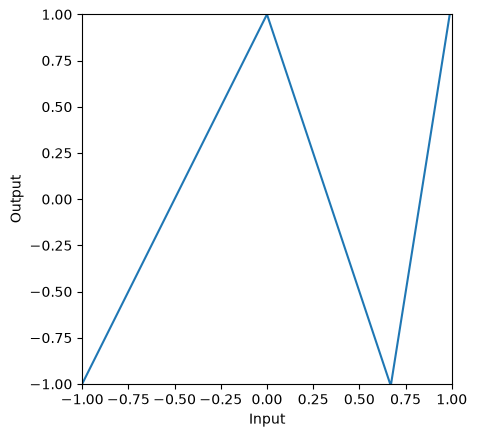

In [6]:
beta_0 = np.zeros((3,1))
Omega_0 = np.zeros((3,1))
beta_1 = np.zeros((1,1))
Omega_1 = np.zeros((1,3))

# Sesgos y pendientes de las unidades ocultas
beta_0[0,0] = n1_theta_10
beta_0[1,0] = n1_theta_20
beta_0[2,0] = n1_theta_30

Omega_0[0,0] = n1_theta_11
Omega_0[1,0] = n1_theta_21
Omega_0[2,0] = n1_theta_31

# Offset y pesos de la capa de salida
beta_1[0,0] = n1_phi_0

Omega_1[0,0] = n1_phi_1
Omega_1[0,1] = n1_phi_2
Omega_1[0,2] = n1_phi_3

# Make sure that input data matrix has different inputs in its columns
n_data = n1_in.size
n_dim_in = 1
n1_in_mat = np.reshape(n1_in,(n_dim_in,n_data))

# This runs the network for ALL of the inputs, x at once so we can draw graph
h1 = ReLU(beta_0 + np.matmul(Omega_0,n1_in_mat))
n1_out = beta_1 + np.matmul(Omega_1,h1)

# Draw the network and check that it looks the same as the non-matrix case
plot_neural(n1_in, n1_out)

Now we'll feed the output of the first network into the second one.

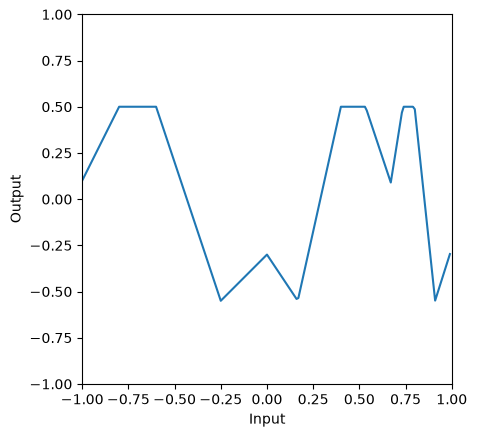

In [8]:
# Now lets define some parameters and run the second neural network
n2_theta_10 =  -0.6 ; n2_theta_11 = -1.0
n2_theta_20 =  0.2  ; n2_theta_21 = 1.0
n2_theta_30 =  -0.5  ; n2_theta_31 =  1.0
n2_phi_0 = 0.5; n2_phi_1 = -1.0; n2_phi_2 = -1.5; n2_phi_3 = 2.0

# Define a range of input values
n2_in = np.arange(-1,1,0.01)

# We run the second neural network on the output of the first network
n2_out, *_ = \
    shallow_1_1_3(n1_out, ReLU, n2_phi_0, n2_phi_1, n2_phi_2, n2_phi_3, n2_theta_10, n2_theta_11, n2_theta_20, n2_theta_21, n2_theta_30, n2_theta_31)
# And then plot it
plot_neural(n1_in, n2_out)

**Solución.** La preactivación de la segunda red es

$$\theta^{(2)}_{i0} + \theta^{(2)}_{i1}\Big(\phi_0 + \sum_j \phi_j h_j\Big) = \underbrace{\big(\theta^{(2)}_{i0} + \theta^{(2)}_{i1}\phi_0\big)}_{\beta_1[i]} + \sum_j \underbrace{\theta^{(2)}_{i1}\phi_j}_{\Omega_1[i,j]} h_j$$

Es decir: la capa de salida de la red 1 y la capa de entrada de la red 2 **se fusionan en una sola** matriz de pesos. `Omega_1` resulta ser el producto externo de la columna $\theta^{(2)}_{i1}$ con la fila $\phi_j$.

Por eso componer dos redes de una capa oculta es exactamente lo mismo que una red de dos capas ocultas.

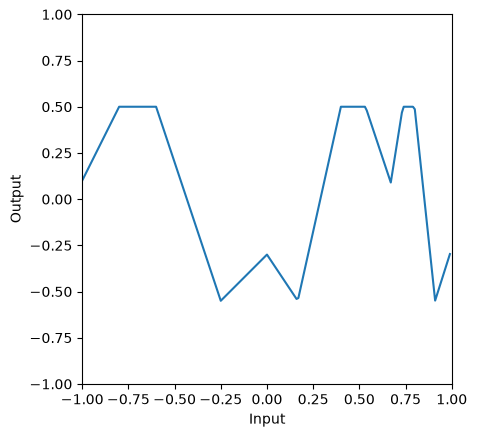

In [9]:
beta_0 = np.zeros((3,1))
Omega_0 = np.zeros((3,1))
beta_1 = np.zeros((3,1))
Omega_1 = np.zeros((3,3))
beta_2 = np.zeros((1,1))
Omega_2 = np.zeros((1,3))

# --- Capa 1: igual que la red 1 ---
beta_0[0,0] = n1_theta_10
beta_0[1,0] = n1_theta_20
beta_0[2,0] = n1_theta_30

Omega_0[0,0] = n1_theta_11
Omega_0[1,0] = n1_theta_21
Omega_0[2,0] = n1_theta_31

# --- Capa 2: fusión de la salida de la red 1 con la entrada de la red 2 ---
beta_1[0,0] = n2_theta_10 + n2_theta_11 * n1_phi_0
beta_1[1,0] = n2_theta_20 + n2_theta_21 * n1_phi_0
beta_1[2,0] = n2_theta_30 + n2_theta_31 * n1_phi_0

Omega_1[0,0] = n2_theta_11 * n1_phi_1
Omega_1[0,1] = n2_theta_11 * n1_phi_2
Omega_1[0,2] = n2_theta_11 * n1_phi_3
Omega_1[1,0] = n2_theta_21 * n1_phi_1
Omega_1[1,1] = n2_theta_21 * n1_phi_2
Omega_1[1,2] = n2_theta_21 * n1_phi_3
Omega_1[2,0] = n2_theta_31 * n1_phi_1
Omega_1[2,1] = n2_theta_31 * n1_phi_2
Omega_1[2,2] = n2_theta_31 * n1_phi_3

# --- Capa de salida: igual que la salida de la red 2 ---
beta_2[0,0] = n2_phi_0

Omega_2[0,0] = n2_phi_1
Omega_2[0,1] = n2_phi_2
Omega_2[0,2] = n2_phi_3

# Make sure that input data matrix has different inputs in its columns
n_data = n1_in.size
n_dim_in = 1
n1_in_mat = np.reshape(n1_in,(n_dim_in,n_data))

# This runs the network for ALL of the inputs, x at once so we can draw graph (hence extra np.ones term)
h1 = ReLU(beta_0 + np.matmul(Omega_0,n1_in_mat))
h2 = ReLU(beta_1 + np.matmul(Omega_1,h1))
n1_out = beta_2 + np.matmul(Omega_2,h2)

# Draw the network and check that it looks the same as the non-matrix version
plot_neural(n1_in, n1_out)

Alternativa compacta para `Omega_1` usando producto externo (equivalente a las nueve asignaciones anteriores):

In [10]:
theta_col = np.array([[n2_theta_11],[n2_theta_21],[n2_theta_31]])   # (3,1)
phi_row   = np.array([[n1_phi_1, n1_phi_2, n1_phi_3]])              # (1,3)

Omega_1_compacta = theta_col @ phi_row

print("¿Coincide con la versión elemento por elemento?", np.allclose(Omega_1, Omega_1_compacta))
print(Omega_1_compacta)

¿Coincide con la versión elemento por elemento? True
[[ 2.   3.  -9.3]
 [-2.  -3.   9.3]
 [-2.  -3.   9.3]]


Now let's make a deep network with 3 hidden layers.  It will have $D_i=4$ inputs, $D_1=5$ neurons  in the first layer, $D_2=2$ neurons in the second layer and $D_3=4$ neurons in the third layer, and $D_o = 1$ output.

**Solución.** La regla de dimensiones es siempre la misma:

$$\boldsymbol\Omega_k:\ (\text{salidas} \times \text{entradas}), \qquad \boldsymbol\beta_k:\ (\text{salidas} \times 1)$$

| Capa | Omega | beta |
|---|---|---|
| 0 | (D_1, D_i) = (5,4) | (5,1) |
| 1 | (D_2, D_1) = (2,5) | (2,1) |
| 2 | (D_3, D_2) = (4,2) | (4,1) |
| 3 | (D_o, D_3) = (1,4) | (1,1) |

Nota: las comprobaciones originales usaban `is not` para comparar enteros, sustituí por `!=`.

In [11]:
# define sizes
D_i=4; D_1=5; D_2=2; D_3=4; D_o=1
# We'll choose the inputs and parameters of this network randomly using np.random.normal
# For example, we'll set the input using
n_data = 4;
x = np.random.normal(size=(D_i, n_data))

# Parámetros con las dimensiones correctas
beta_0  = np.random.normal(size=(D_1,1))
Omega_0 = np.random.normal(size=(D_1,D_i))
beta_1  = np.random.normal(size=(D_2,1))
Omega_1 = np.random.normal(size=(D_2,D_1))
beta_2  = np.random.normal(size=(D_3,1))
Omega_2 = np.random.normal(size=(D_3,D_2))
beta_3  = np.random.normal(size=(D_o,1))
Omega_3 = np.random.normal(size=(D_o,D_3))

# If you set the parameters to the correct sizes, the following code will run
h1 = ReLU(beta_0 + np.matmul(Omega_0,x));
h2 = ReLU(beta_1 + np.matmul(Omega_1,h1));
h3 = ReLU(beta_2 + np.matmul(Omega_2,h2));
y = beta_3 + np.matmul(Omega_3,h3)

if h1.shape[0] != D_1 or h1.shape[1] != n_data:
  print("h1 is wrong shape")
if h2.shape[0] != D_2 or h2.shape[1] != n_data:
  print("h2 is wrong shape")
if h3.shape[0] != D_3 or h3.shape[1] != n_data:
  print("h3 is wrong shape")
if y.shape[0] != D_o or y.shape[1] != n_data:
  print("Output is wrong shape")

# Print the inputs and outputs
print("Input data points")
print(x)
print ("Output data points")
print(y)

Input data points
[[-0.95260719 -0.14193857 -0.4702436   0.8453901 ]
 [ 0.11434664 -0.62938671  2.68076769 -0.55940308]
 [-0.46147677  0.07422386 -0.05619781  0.35295352]
 [-0.7807069   0.42258398 -1.6167485   1.29534222]]
Output data points
[[-0.16808832  0.15293255 -0.16808832 -0.06086177]]


In [12]:
# Verificación explícita de las formas de cada capa
for nombre, arr in [("x ", x), ("h1", h1), ("h2", h2), ("h3", h3), ("y ", y)]:
    print(f"{nombre}: {arr.shape}")

x : (4, 4)
h1: (5, 4)
h2: (2, 4)
h3: (4, 4)
y : (1, 4)
